In [2]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [3]:

load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [4]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [5]:
def generate_joke(state: JokeState) -> dict:
    prompt = f"Generate a funny joke on the topic: {state['topic']}"
    response = model.invoke(prompt)
    return {"joke": response.content}

def generate_explanation(state: JokeState) -> dict:
    prompt = f"Write a brief explanation for this joke:\n{state['joke']}"
    response = model.invoke(prompt)
    return {"explanation": response.content}

In [6]:
# Create the checkpointer — saves state to RAM
checkpointer = MemorySaver()

graph = StateGraph(JokeState)
graph.add_node("generate_joke", generate_joke)
graph.add_node("generate_explanation", generate_explanation)
graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "generate_explanation")
graph.add_edge("generate_explanation", END)

# Pass checkpointer at compile time — this enables persistence
workflow = graph.compile(checkpointer=checkpointer)

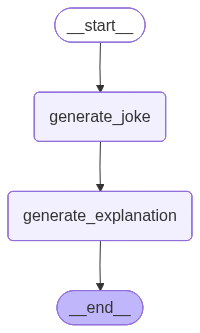

In [7]:
workflow

In [8]:
# Thread ID identifies this specific run
config_1 = {"configurable": {"thread_id": "1"}}

result = workflow.invoke(
    {"topic": "pizza"},
    config=config_1
)
print(result["joke"])
print(result["explanation"])

I ordered a pizza and the delivery guy asked me if I wanted to hear a joke.

I said, "Sure!"

He said, "Never mind, it's too cheesy."
This joke is a pun on the word "cheesy":

1.  **Literal Meaning:** Pizza is literally "cheesy" because it's covered in cheese.
2.  **Idiomatic Meaning:** "Cheesy" is also an idiom used to describe something that is corny, unoriginal, or trying too hard to be funny (like a bad joke).

The humor comes from the delivery guy using the word in both senses, cleverly linking the idea of a "corny" joke to the "cheesy" product he's delivering.


In [9]:
# Get the saved final state for thread "1"
final_state = workflow.get_state(config=config_1)
print(final_state.values)
# Shows: topic="pizza", joke="...", explanation="..."

{'topic': 'pizza', 'joke': 'I ordered a pizza and the delivery guy asked me if I wanted to hear a joke.\n\nI said, "Sure!"\n\nHe said, "Never mind, it\'s too cheesy."', 'explanation': 'This joke is a pun on the word "cheesy":\n\n1.  **Literal Meaning:** Pizza is literally "cheesy" because it\'s covered in cheese.\n2.  **Idiomatic Meaning:** "Cheesy" is also an idiom used to describe something that is corny, unoriginal, or trying too hard to be funny (like a bad joke).\n\nThe humor comes from the delivery guy using the word in both senses, cleverly linking the idea of a "corny" joke to the "cheesy" product he\'s delivering.'}


In [10]:
# Get ALL saved checkpoints for thread "1"
state_history = list(workflow.get_state_history(config=config_1))

for checkpoint in state_history:
    print("Values:", checkpoint.values)
    print("Next node:", checkpoint.next)
    print("---")

Values: {'topic': 'pizza', 'joke': 'I ordered a pizza and the delivery guy asked me if I wanted to hear a joke.\n\nI said, "Sure!"\n\nHe said, "Never mind, it\'s too cheesy."', 'explanation': 'This joke is a pun on the word "cheesy":\n\n1.  **Literal Meaning:** Pizza is literally "cheesy" because it\'s covered in cheese.\n2.  **Idiomatic Meaning:** "Cheesy" is also an idiom used to describe something that is corny, unoriginal, or trying too hard to be funny (like a bad joke).\n\nThe humor comes from the delivery guy using the word in both senses, cleverly linking the idea of a "corny" joke to the "cheesy" product he\'s delivering.'}
Next node: ()
---
Values: {'topic': 'pizza', 'joke': 'I ordered a pizza and the delivery guy asked me if I wanted to hear a joke.\n\nI said, "Sure!"\n\nHe said, "Never mind, it\'s too cheesy."'}
Next node: ('generate_explanation',)
---
Values: {'topic': 'pizza'}
Next node: ('generate_joke',)
---
Values: {}
Next node: ('__start__',)
---


In [11]:
# Thread ID identifies this specific run
config_2 = {"configurable": {"thread_id": "2"}}

result = workflow.invoke(
    {"topic": "pasta"},
    config=config_2
)
print(result["joke"])
print(result["explanation"])

What do you call a noodle that's pretending to be something else?
An **impasta!**
This is a pun!

The joke plays on the word **"impostor,"** which means someone who pretends to be someone else to deceive others.

By replacing the "o" in "impostor" with "a," and relating it to a "noodle" (which is **pasta**), you get **"impasta"** – a noodle pretending to be something else, just like an impostor.


In [12]:
final_state = workflow.get_state(config=config_2)
print(final_state.values)

{'topic': 'pasta', 'joke': "What do you call a noodle that's pretending to be something else?\nAn **impasta!**", 'explanation': 'This is a pun!\n\nThe joke plays on the word **"impostor,"** which means someone who pretends to be someone else to deceive others.\n\nBy replacing the "o" in "impostor" with "a," and relating it to a "noodle" (which is **pasta**), you get **"impasta"** – a noodle pretending to be something else, just like an impostor.'}


In [13]:
# Get ALL saved checkpoints for thread "1"
state_history = list(workflow.get_state_history(config=config_2))

for checkpoint in state_history:
    print("Values:", checkpoint.values)
    print("Next node:", checkpoint.next)
    print("---")

Values: {'topic': 'pasta', 'joke': "What do you call a noodle that's pretending to be something else?\nAn **impasta!**", 'explanation': 'This is a pun!\n\nThe joke plays on the word **"impostor,"** which means someone who pretends to be someone else to deceive others.\n\nBy replacing the "o" in "impostor" with "a," and relating it to a "noodle" (which is **pasta**), you get **"impasta"** – a noodle pretending to be something else, just like an impostor.'}
Next node: ()
---
Values: {'topic': 'pasta', 'joke': "What do you call a noodle that's pretending to be something else?\nAn **impasta!**"}
Next node: ('generate_explanation',)
---
Values: {'topic': 'pasta'}
Next node: ('generate_joke',)
---
Values: {}
Next node: ('__start__',)
---


# Fault Tolerance

In [14]:
import time
from typing import TypedDict

class StepState(TypedDict):
    input: str
    step_one: str
    step_two: str
    step_three: str

def step_one(state: StepState) -> dict:
    print("Step One executed")
    return {"step_one": "done"}

def step_two(state: StepState) -> dict:
    print("Step Two running... (30 second delay)")
    time.sleep(30)   # simulates a slow/crashing step
    return {"step_two": "done"}

def step_three(state: StepState) -> dict:
    print("Step Three executed")
    return {"step_three": "done"}

checkpointer = MemorySaver()
graph = StateGraph(StepState)
graph.add_node("step_one", step_one)
graph.add_node("step_two", step_two)
graph.add_node("step_three", step_three)
graph.add_edge(START, "step_one")
graph.add_edge("step_one", "step_two")
graph.add_edge("step_two", "step_three")
graph.add_edge("step_three", END)
workflow2 = graph.compile(checkpointer=checkpointer)


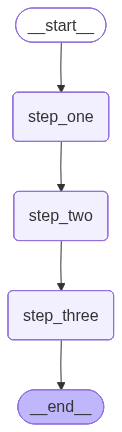

In [15]:
workflow2

In [16]:

config = {"configurable": {"thread_id": "fault_test"}}

# Run — interrupt manually during step_two (Ctrl+C)
try:
    workflow2.invoke({"input": "start"}, config=config)
except KeyboardInterrupt:
    print("Workflow interrupted — simulating crash")

Step One executed
Step Two running... (30 second delay)
Step Three executed


In [17]:
# Check where it stopped
state = workflow2.get_state(config=config)
print("State when crashed:", state.values)
# Shows: step_one="done", step_two NOT set yet

State when crashed: {'input': 'start', 'step_one': 'done', 'step_two': 'done', 'step_three': 'done'}


In [18]:

# RESUME — pass None as input to resume from last checkpoint
result = workflow2.invoke(None, config=config)
print("Resumed successfully:", result)
# Picks up at step_two, NOT from step_one

Resumed successfully: {'input': 'start', 'step_one': 'done', 'step_two': 'done', 'step_three': 'done'}


In [19]:
# Get ALL saved checkpoints for thread "1"
state_history = list(workflow2.get_state_history(config=config))

for checkpoint in state_history:
    print("Values:", checkpoint.values)
    print("Next node:", checkpoint.next)
    print("---")

Values: {'input': 'start', 'step_one': 'done', 'step_two': 'done', 'step_three': 'done'}
Next node: ()
---
Values: {'input': 'start', 'step_one': 'done', 'step_two': 'done'}
Next node: ('step_three',)
---
Values: {'input': 'start', 'step_one': 'done'}
Next node: ('step_two',)
---
Values: {'input': 'start'}
Next node: ('step_one',)
---
Values: {}
Next node: ('__start__',)
---


# Time Travel

In [ ]:
# Run pizza joke
config_1 = {"configurable": {"thread_id": "pizza"}}
workflow.invoke({"topic": "pizza"}, config=config_1)

# Get history and find the checkpoint where topic="pizza" but joke hasn't been generated yet
history = list(workflow.get_state_history(config=config_1))

# Find the checkpoint just before generate_joke ran
target_checkpoint = None
for checkpoint in history:
    if checkpoint.values.get("topic") == "pizza" and not checkpoint.values.get("joke"):
        target_checkpoint = checkpoint
        break

# Replay from that checkpoint — generates a NEW (different) joke for pizza
replay_config = {
    "configurable": {
        "thread_id": "pizza",
        "checkpoint_id": target_checkpoint.config["configurable"]["checkpoint_id"]
    }
}
result = workflow.invoke(None, config=replay_config)
print("New joke:", result["joke"])  # Different from the first run

# Modify state and replay with a different topic
workflow.update_state(
    config=replay_config,
    values={"topic": "samosa"}   # change topic before re-running
)

# Now re-run from the updated checkpoint
new_result = workflow.invoke(None, config=replay_config)
print("Samosa joke:", new_result["joke"])